In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from matplotlib import rc

import os, re
import numpy as np
import pandas as pd


In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']  # Font name from file
plt.rcParams['font.size'] = 14


In [3]:
from matplotlib import font_manager as fm
font_path = "/home/a.burov/fonts/ARIAL.TTF"
fm.fontManager.addfont(font_path)


In [4]:
np.set_printoptions(precision=8)

In [5]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [6]:
# %matplotlib inline
plt.rcParams['figure.dpi'] = 450


In [7]:
API_KEY = "LTSM6dStBrl69FjopxP7KdZBP35B1yh7"

In [8]:
layered_list = [
    "layered_p1", 
    "layered_p-1", 
    "layered_p2c", 
    "layered_p21", 
    "layered_p21c", 
]


In [9]:
diaspore_list = [
    "alpha",
    "beta", 
    "gamma", 
    "delta", 
]


In [ ]:
data_path = {
    # "sevennet" : "/home/a.burov/icys_2025/niohf/umlip_phonons/sevennet", 
    # "alignn" : "/home/a.burov/icys_2025/niohf/umlip_phonons/alignn",     
    "fairchem" : "/home/a.burov/icys_2025/niohf/umlip_phonons/fairchem/",
    "tace" : "/home/a.burov/icys_2025/niohf/umlip_phonons/tace/",
    "prophet" : "/home/a.burov/icys_2025/niohf/umlip_phonons/prophet/",
}


In [ ]:
import sys
from pathlib import Path

def _repo_root():
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "plot_colors.py").is_file():
            return cand
    raise FileNotFoundError("plot_colors.py not found from " + str(here))

sys.path.insert(0, str(_repo_root()))
from plot_colors import series_colors

_dia_names = ["alpha", "beta", "gamma", "delta"]
colors_diaspore = dict(zip(_dia_names, series_colors(len(_dia_names))))


In [ ]:
_lay_names = ["layered_p1", "layered_p-1", "layered_p2c", "layered_p21", "layered_p21c"]
colors_layered = dict(zip(_lay_names, series_colors(len(_lay_names))))


## Diaspores

In [13]:
def sort_phases_by_energy_at_temp(data_dict, target_temp=600.0):
    """
    Sort dictionary by Gibbs energy values at specific temperature.
    Returns ordered list of phases (lowest energy first = most stable).
    """
    phase_energies = {}
    
    for phase_key, (temps, energies) in data_dict.items():
        # Find closest temperature index to target
        idx = np.argmin(np.abs(temps - target_temp))
        energy_at_temp = energies[idx]
        phase_energies[phase_key] = energy_at_temp
    
    # Sort by energy (ascending = most stable first)
    sorted_phases = sorted(phase_energies.items(), key=lambda x: x[1])
    
    return sorted_phases

    

In [14]:
import numpy as np

def calculate_delta_lowest_second(data_dict, target_temp=600.0):
    """
    Calculate delta = E_2nd_lowest - E_lowest at target temperature.
    Returns delta energy difference (meV) and phase info.
    """
    phase_energies = {}
    
    # Extract energies at target temperature
    for phase_key, (temps, energies) in data_dict.items():
        idx = np.argmin(np.abs(temps - target_temp))
        energy_at_temp = energies[idx]
        phase_energies[phase_key] = energy_at_temp
    
    # Sort phases by energy (ascending)
    sorted_phases = sorted(phase_energies.items(), key=lambda x: x[1])
    
    # Get lowest and second lowest
    lowest_phase, E_lowest = sorted_phases[0]
    second_phase, E_second = sorted_phases[1]
    
    # Calculate delta (positive value)
    delta_eV = E_second - E_lowest
    delta_meV = delta_eV * 1000  # Convert to meV (standard for phase stability)
    
    return {
        'delta_eV': delta_eV,
        'delta_meV': delta_meV,
        'lowest_phase': lowest_phase,
        'E_lowest': E_lowest,
        'second_phase': second_phase,
        'E_second': E_second
    }



saved /home/a.burov/icys_2025/niohf/data/figures/gibbs_fairchem


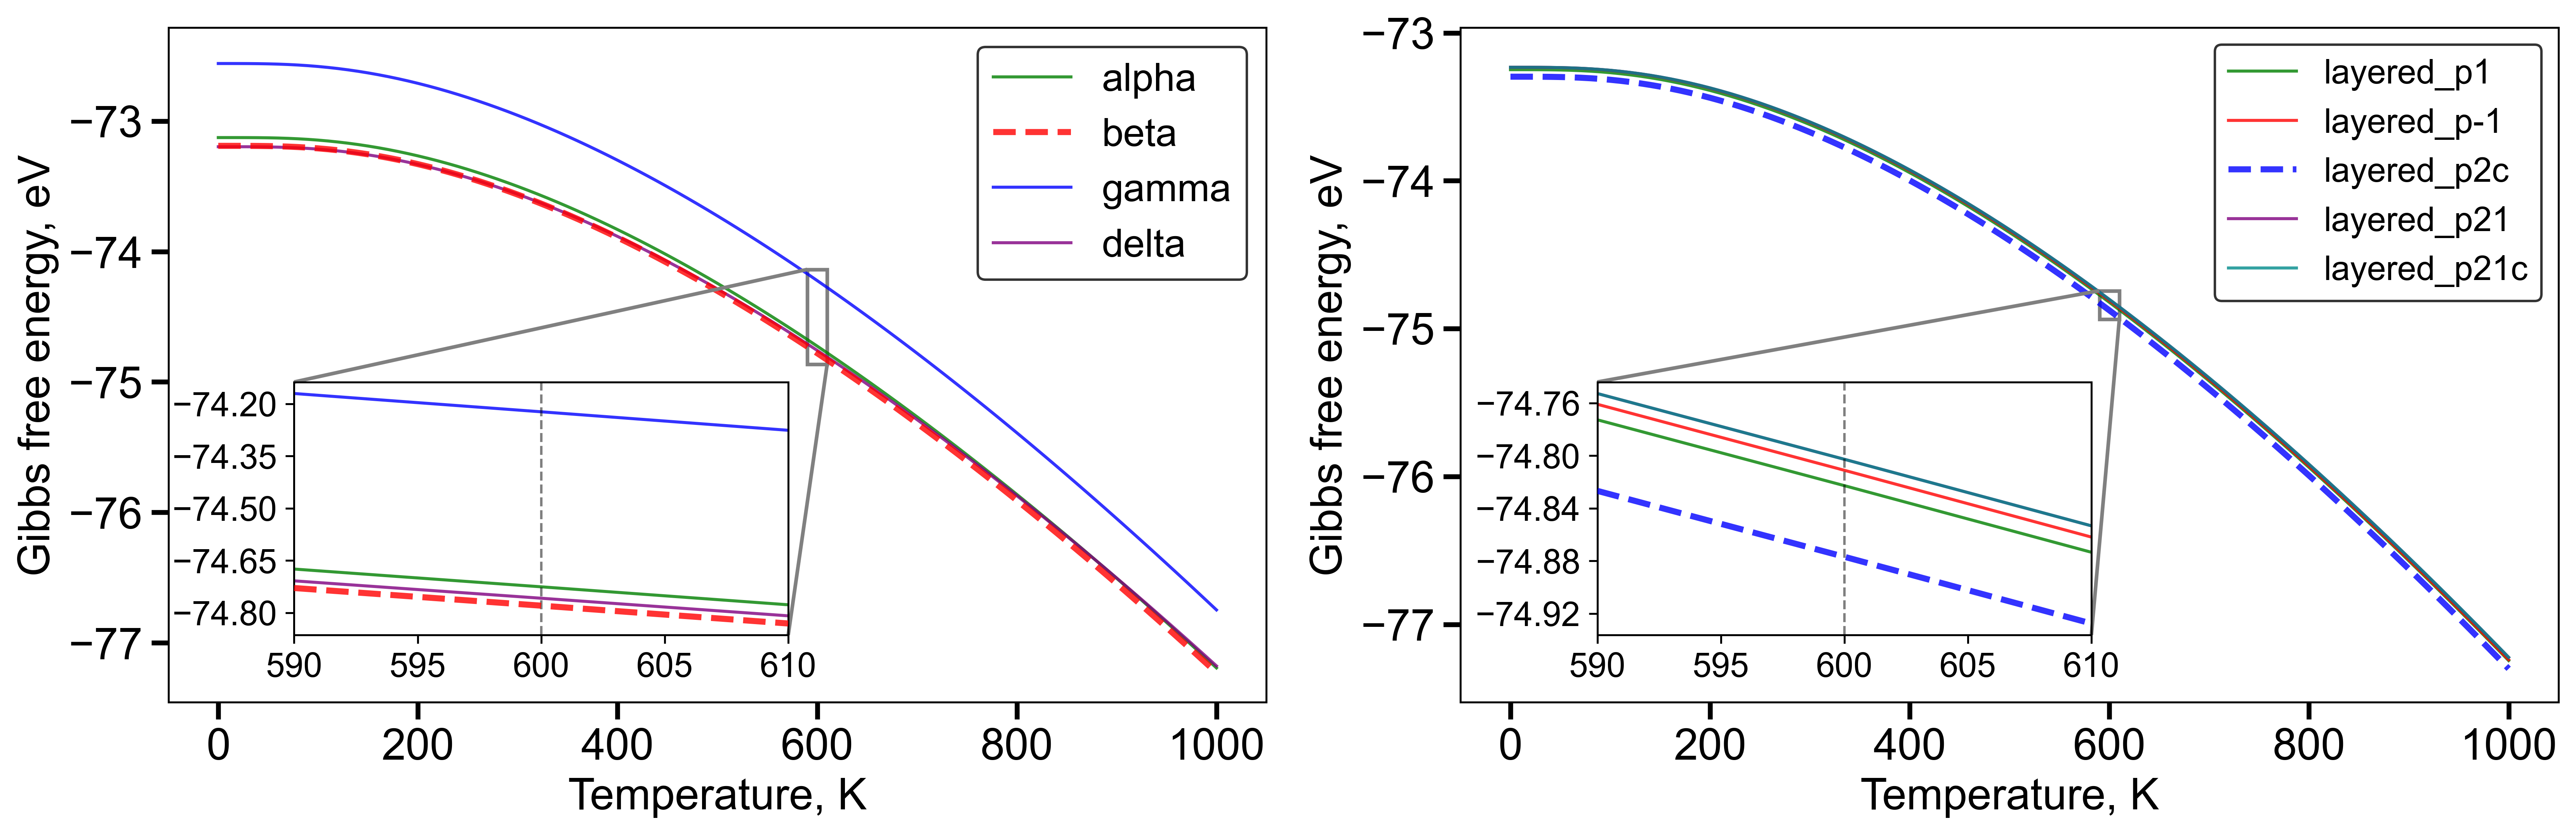

In [15]:
fontsize = 18
lw = 1.25
width = 0.3
center = 600
thresh = 10
fig_dir = "/home/a.burov/icys_2025/niohf/data/figures"


def _phase_name(key):
    """sort_phases_by_energy_at_temp keys may be phase str or (umlip, phase)."""
    if isinstance(key, (tuple, list)):
        return key[-1]
    return key


def _load_gibbs(root, phases):
    data_dict = {}
    all_y = []
    for st in phases:
        fpath = os.path.join(root, st, "gibbs-temperature.dat")
        if not os.path.isfile(fpath):
            print(f"skip missing {fpath}")
            continue
        data = np.loadtxt(fpath)
        data_x, data_y = data[:, 0], data[:, 1]
        data_dict[st] = (data_x, data_y)
        all_y.extend(data_y)
    return data_dict, (np.asarray(all_y) if all_y else np.array([]))


def _style_ax(ax):
    ax.set_ylabel(r"Gibbs free energy, eV", fontsize=fontsize)
    ax.set_xlabel(r"Temperature, K", fontsize=fontsize)
    ax.tick_params(axis="both", which="major", labelsize=fontsize)
    ax.tick_params(axis="both", which="minor", labelsize=fontsize - 2)
    ax.yaxis.get_offset_text().set_fontsize(10)
    ax.xaxis.set_tick_params(width=2, length=7)
    ax.yaxis.set_tick_params(width=2, length=7)


def _plot_family(ax, data_dict, colors, highlight_phase=None):
    for st, (data_x, data_y) in data_dict.items():
        if st == highlight_phase:
            lw_plot, style, order = lw * 2, "--", 3
        else:
            lw_plot, style, order = lw, "-", 2
        ax.plot(
            data_x, data_y, style, linewidth=lw_plot, label=st,
            color=colors[st], alpha=0.8, zorder=order,
        )


def _add_inset(ax, data_dict, colors, highlight_phase=None, bbox=(0.28, 0.25, 0.3, 0.25)):
    inset = inset_axes(
        ax, width="150%", height="150%", loc="upper right",
        bbox_to_anchor=bbox, bbox_transform=ax.transAxes,
    )
    inset.yaxis.set_major_locator(plt.MaxNLocator(5))
    for st, (data_x, data_y) in data_dict.items():
        mask = (data_x >= center - thresh) & (data_x <= center + thresh)
        if st == highlight_phase:
            lw_plot, style, order = lw * 2, "--", 3
        else:
            lw_plot, style, order = lw, "-", 2
        inset.plot(
            data_x[mask], data_y[mask], style, linewidth=lw_plot,
            color=colors[st], alpha=0.8, zorder=order,
        )
    inset.axvline(center, color="black", linestyle="--", alpha=0.5, linewidth=1.0)
    inset.set_xlim(center - thresh, center + thresh)
    inset.tick_params(labelsize=fontsize - 4)
    mark_inset(ax, inset, loc1=2, loc2=4, fc="none", ec="0.5", lw=1.5)
    return inset


os.makedirs(fig_dir, exist_ok=True)

for umlip, path in data_path.items():
    dia, y_dia = _load_gibbs(path, diaspore_list)
    lay, y_lay = _load_gibbs(path, layered_list)
    if not dia and not lay:
        print(f"no Gibbs data for {umlip}")
        continue

    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=450)
    _style_ax(ax)
    _style_ax(ax2)

    highlight_dia = None
    if dia:
        list_sorted_dia = sort_phases_by_energy_at_temp(dia, target_temp=center)
        highlight_dia = _phase_name(list_sorted_dia[0][0])
        _plot_family(ax, dia, colors_diaspore, highlight_dia)
        y_low, y_high = 0.99 * y_dia.min(), 1.01 * y_dia.max()
        ax.set_ylim(y_low - 1.0, y_high + 1.0)
        ax.legend(fontsize=fontsize - 2, loc=1, edgecolor="black")

    highlight_lay = None
    result = None
    data_dict = lay
    if lay:
        list_sorted = sort_phases_by_energy_at_temp(lay, target_temp=center)
        highlight_lay = _phase_name(list_sorted[0][0])
        if len(lay) >= 2:
            result = calculate_delta_lowest_second(lay, target_temp=center)
        _plot_family(ax2, lay, colors_layered, highlight_lay)
        y_low, y_high = 0.99 * y_lay.min(), 1.01 * y_lay.max()
        ax2.set_ylim(y_low - 1.0, y_high + 1.0)
        ax2.legend(fontsize=fontsize - 4, loc=1, edgecolor="black")

    # tight_layout before insets — otherwise inset_axes is parented to the wrong panel
    fig.tight_layout()

    if dia:
        _add_inset(ax, dia, colors_diaspore, highlight_dia, bbox=(0.28, 0.25, 0.3, 0.25))
    if lay:
        _add_inset(ax2, lay, colors_layered, highlight_lay, bbox=(0.29, 0.25, 0.3, 0.25))

    fig.savefig(f"{fig_dir}/gibbs_{umlip}.png", dpi=450)
    fig.savefig(f"{fig_dir}/gibbs_{umlip}.pdf", dpi=450)
    print(f"saved {fig_dir}/gibbs_{umlip}")
    plt.show()
    plt.close(fig)


In [16]:
thresh

10

In [17]:
# data_dict

In [18]:
# USAGE:
def _phase_label(key):
    if isinstance(key, (tuple, list)) and len(key) >= 2:
        return f"{key[-1]} ({key[0]})"
    return str(key)

result = calculate_delta_lowest_second(data_dict, target_temp=600)

print(f"Phase stability at T=600K:")
print(f"Lowest:     {_phase_label(result['lowest_phase'])} = {result['E_lowest']:.6f} eV")
print(f"2nd lowest: {_phase_label(result['second_phase'])} = {result['E_second']:.6f} eV")
print(f"ΔE = {result['delta_meV']:.2f} meV ← Energy difference to next stable phase")


Phase stability at T=600K:
Lowest:     layered_p2c = -74.876837 eV
2nd lowest: layered_p1 = -74.822767 eV
ΔE = 54.07 meV ← Energy difference to next stable phase
